# Процессинг

In [18]:
from urllib.request import urlretrieve

In [ ]:
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.multioutput import MultiOutputRegressor

from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import matplotlib.pyplot as plt
from sklearn.feature_selection import VarianceThreshold
from sklearn import set_config

import optuna

from sklearn.metrics import root_mean_squared_error

from sklearn.ensemble import (
    RandomForestRegressor
)

set_config(transform_output="pandas")

warnings.filterwarnings("ignore")

In [20]:
FILES = {
    "test.csv": "1Ui2t87X3in-Wu-pnjkDXa_VtPsVafi0l",
    "train.csv": "159PZX3X5rpUO-WbzWyC9whnc8B4mNqJl",
    "sample_submission.csv": "1LL6moSzpUVxJUTMeXihWvUxBJNjvj6EH",
}

TARGETS = ['IC50', 'CC50', 'SI']

for filename, file_id in FILES.items():
    if not Path(filename).is_file():
        url = f"https://drive.google.com/uc?id={file_id}"
        print(f"Downloading {filename}...")
        urlretrieve(url, filename)

sumbission_test = pd.read_csv("test.csv").set_index("index")
df = pd.read_csv("train.csv").set_index("index")
df.rename(columns={"IC50, mM": "IC50", "CC50, mM": "CC50"}, inplace=True)
Y = df[TARGETS]
X = df.drop(TARGETS, axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

In [21]:
class AddFeatures(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        X["TPSA_LogP"] = X["TPSA"] / (X["MolLogP"].abs() + 1)
        X["AromaticRingFrac"] = (
            X["NumAromaticRings"] / (X["RingCount"] + 1)
        )
        X["Flexibility"] = (
            X["NumRotatableBonds"] / (X["RingCount"] + 1)
        )
        X["HBondBalance"] = (
            X["NumHDonors"] / (X["NumHAcceptors"] + 1)
        )
        X["HeteroDensity"] = (
            X["NumHeteroatoms"] / (X["MolWt"] + 1)
        )
        X["RingComplexity"] = (
            X["RingCount"] * X["FractionCSP3"]
        )
        X['hetero_ratio']        = X['NumHeteroatoms']    / (X['HeavyAtomCount'] + 1)
        X['donor_acceptor_sum']  = X['NumHDonors']        + X['NumHAcceptors']
        X['donor_acceptor_ratio']= X['NumHDonors']        / (X['NumHAcceptors'] + 1)
        X['rotatable_per_heavy'] = X['NumRotatableBonds'] / (X['HeavyAtomCount'] + 1)
        X['rings_per_heavy']     = X['RingCount']         / (X['HeavyAtomCount'] + 1)
        X['aromatic_ratio']      = X['NumAromaticRings']  / (X['RingCount'] + 1)
        X['tpsa_per_heavy']      = X['TPSA']              / (X['HeavyAtomCount'] + 1)
        X['mol_logp_per_heavy']  = X['MolLogP']           / (X['HeavyAtomCount'] + 1)
        X['mol_mr_per_molwt']    = X['MolMR']             / (X['MolWt'] + 1)
    
        # Агрегаты по группам дескрипторов
        fr_cols     = [c for c in X.columns if c.startswith('fr_')]
        vsa_cols    = [c for c in X.columns if 'VSA' in c]
        estate_cols = [c for c in X.columns if 'EState' in c]
    
        X['fr_total']         = X[fr_cols].sum(axis=1)
        X['fr_nonzero_count'] = (X[fr_cols] > 0).sum(axis=1)
        X['vsa_total']        = X[vsa_cols].sum(axis=1)
        X['vsa_nonzero_count']= (X[vsa_cols] > 0).sum(axis=1)
        X['estate_abs_sum']   = X[estate_cols].abs().sum(axis=1)
        return X

class DropConstantColumns(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        self.keep_cols_ = X.columns[X.nunique() > 1]
        return self

    def transform(self, X):
        return X[self.keep_cols_]

class DropDuplicateColumns(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        seen = {}
        self.keep_cols_ = []

        for col in X.columns:
            key = tuple(X[col].values)
            if key not in seen:
                seen[key] = col
                self.keep_cols_.append(col)

        return self

    def transform(self, X):
        return X[self.keep_cols_]

class DropCorrelatedColumns(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.95):
        self.threshold = threshold

    def fit(self, X, y=None):
        corr_matrix = X.corr().abs()

        upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

        self.keep_cols_ = [column for column in upper.columns if not any(upper[column] > self.threshold) and column != "MinEStateIndex"]
        return self

    def transform(self, X):
        return X[self.keep_cols_]

In [22]:
x_pipeline = Pipeline([
    ("addshit", AddFeatures()),
    ("duplicates", DropDuplicateColumns()),
    ("correlation", DropCorrelatedColumns(0.99)),
    ("variance", VarianceThreshold(threshold=1e-5)),
    ("imputer", SimpleImputer(strategy="median")),
])

X_train_p = x_pipeline.fit_transform(X_train)
X_test_p = x_pipeline.transform(X_test)

In [23]:
RANDOM_STATE = 42

N_SPLITS = 5
N_TRIALS = 70

USE_LOG_TARGET = True

cv = KFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

TARGET_COLUMNS = y_train.columns.tolist()

if USE_LOG_TARGET:
    y_train_fit = np.log1p(y_train)
else:
    y_train_fit = y_train.copy()

all_results = []
best_models = {}


def evaluate_final_model(name, model):

    model.fit(X_train_p, y_train_fit)

    preds = model.predict(X_test_p)

    if USE_LOG_TARGET:
        preds = np.expm1(preds)

    preds = np.clip(preds, 0, None)

    rmse = root_mean_squared_error(y_test, preds)

    print(f"\n{name} TEST RMSE: {rmse:.6f}")

    return rmse

def optimize_model(
    name,
    model_builder,
    objective_builder
):

    print("\n" + "=" * 70)
    print(f"OPTIMIZING: {name}")
    print("=" * 70)
    
    study = optuna.create_study(
        direction="minimize",
        sampler=optuna.samplers.TPESampler(
            seed=RANDOM_STATE
        ),
        pruner=optuna.pruners.MedianPruner()
    )

    study.optimize(
        objective_builder(model_builder),
        n_trials=N_TRIALS,
        show_progress_bar=True
    )

    print("\nBEST PARAMS:")
    print(study.best_params)

    print(f"\nBEST CV RMSE: {study.best_value:.6f}")

    best_model = model_builder(study.best_params)

    test_rmse = evaluate_final_model(
        name,
        best_model
    )

    best_models[name] = best_model

    all_results.append({
        "Model": name,
        "CV_RMSE": study.best_value,
        "Test_RMSE": test_rmse,
        "Params": study.best_params
    })

def make_objective(model_builder):

    def objective(trial):

        params = model_builder(trial, return_params=True)

        model = model_builder(params)

        scores = cross_val_score(
            model,
            X_train_p,
            y_train_fit,
            scoring="neg_root_mean_squared_error",
            cv=cv,
            n_jobs=1
        )

        rmse = -scores.mean()

        return rmse

    return objective

def build_xgb(x, return_params=False):

    if return_params:

        return {
            "n_estimators": x.suggest_int("n_estimators", 100, 1000),
            "max_depth": x.suggest_int("max_depth", 3, 14),
            "learning_rate": x.suggest_float(
                "learning_rate",
                0.01,
                0.2,
                log=True
            ),
            "subsample": x.suggest_float("subsample", 0.3, 1.0),
            "colsample_bytree": x.suggest_float(
                "colsample_bytree",
                0.3,
                1.0
            ),
            "reg_alpha": x.suggest_float(
                "reg_alpha",
                1e-5,
                10,
                log=True
            ),
            "reg_lambda": x.suggest_float(
                "reg_lambda",
                1e-5,
                10,
                log=True
            )
        }

    return MultiOutputRegressor(
        XGBRegressor(
            random_state=RANDOM_STATE,
            tree_method="hist",
            device="cuda",
            objective="reg:squarederror",
            eval_metric="rmse",
            **x
        )
    )


def build_lgbm(x, return_params=False):

    if return_params:

        return {
            "n_estimators": x.suggest_int("n_estimators", 100, 800),
            "learning_rate": x.suggest_float(
                "learning_rate",
                0.001,
                0.2,
                log=True
            ),
            "num_leaves": x.suggest_int("num_leaves", 16, 128),
            "max_depth": x.suggest_int("max_depth", 3, 15),
            "subsample": x.suggest_float("subsample", 0.6, 1.0),
            "colsample_bytree": x.suggest_float(
                "colsample_bytree",
                0.6,
                1.0
            ),
            "min_child_samples": x.suggest_int(
                "min_child_samples",
                5,
                50
            )
        }

    return MultiOutputRegressor(
        LGBMRegressor(
            random_state=RANDOM_STATE,
            verbose=-1,
            **x
        )
    )

def build_catboost(x, return_params=False):

    if return_params:

        return {
            "iterations": x.suggest_int("iterations", 100, 600),
            "depth": x.suggest_int("depth", 4, 11),
            "learning_rate": x.suggest_float(
                "learning_rate",
                0.01,
                0.2,
                log=True
            ),
            "l2_leaf_reg": x.suggest_float(
                "l2_leaf_reg",
                1,
                10 
            )
        }

    return MultiOutputRegressor(
        CatBoostRegressor(
            random_state=RANDOM_STATE,
            task_type="CPU",
            verbose=0,
            boosting_type="Plain",
            thread_count=-1,
            **x
        )
    )

def build_rf(x, return_params=False):

    if return_params:

        return {
            "n_estimators": x.suggest_int("n_estimators", 100, 1000),
            "max_depth": x.suggest_int("max_depth", 4, 30),
            "min_samples_split": x.suggest_int(
                "min_samples_split",
                2,
                10
            ),
            "min_samples_leaf": x.suggest_int(
                "min_samples_leaf",
                1,
                10
            ),
            "max_features": x.suggest_categorical(
                "max_features",
                ["sqrt", "log2", None]
            )
        }

    return MultiOutputRegressor(
        RandomForestRegressor(
            random_state=RANDOM_STATE,
            n_jobs=-1,
            **x
        )
    )


# optimize_model(
#     "XGBoost",
#     build_xgb,
#     make_objective
# )

optimize_model(
    "LightGBM",
    build_lgbm,
    make_objective
)

# optimize_model(
#     "CatBoost",
#     build_catboost,
#     make_objective
# )

# optimize_model(
#     "RandomForest",
#     build_rf,
#     make_objective
# )

results_df = pd.DataFrame(all_results)

results_df = results_df.sort_values(
    "Test_RMSE"
).reset_index(drop=True)

print("\n")
print("=" * 70)
print("FINAL RESULTS")
print("=" * 70)

print(results_df)

[I 2026-05-25 00:25:44,015] A new study created in memory with name: no-name-fdb23a6e-3546-44df-aadd-bcd5143fb8b3



OPTIMIZING: LightGBM


Best trial: 0. Best value: 1.37883:   1%|▏         | 1/70 [00:02<02:29,  2.17s/it]

[I 2026-05-25 00:25:46,185] Trial 0 finished with value: 1.378825834686682 and parameters: {'n_estimators': 362, 'learning_rate': 0.1540359659501924, 'num_leaves': 98, 'max_depth': 10, 'subsample': 0.6624074561769746, 'colsample_bytree': 0.662397808134481, 'min_child_samples': 7}. Best is trial 0 with value: 1.378825834686682.


Best trial: 1. Best value: 1.3317:   3%|▎         | 2/70 [00:03<01:48,  1.59s/it] 

...

[I 2026-05-25 00:27:36,635] Trial 67 finished with value: 1.321849859239289 and parameters: {'n_estimators': 596, 'learning_rate': 0.01955248889821275, 'num_leaves': 106, 'max_depth': 7, 'subsample': 0.9555456782085212, 'colsample_bytree': 0.822717932984804, 'min_child_samples': 32}. Best is trial 16 with value: 1.3090516307705937.


Best trial: 16. Best value: 1.30905:  99%|█████████▊| 69/70 [01:54<00:01,  1.53s/it]

[I 2026-05-25 00:27:38,187] Trial 68 finished with value: 1.3160788036584121 and parameters: {'n_estimators': 686, 'learning_rate': 0.014988693234013665, 'num_leaves': 92, 'max_depth': 10, 'subsample': 0.7862779372792024, 'colsample_bytree': 0.8420511581201725, 'min_child_samples': 42}. Best is trial 16 with value: 1.3090516307705937.


Best trial: 16. Best value: 1.30905: 100%|██████████| 70/70 [01:55<00:00,  1.65s/it]


[I 2026-05-25 00:27:39,729] Trial 69 finished with value: 1.3192442657779266 and parameters: {'n_estimators': 715, 'learning_rate': 0.005857325868812835, 'num_leaves': 98, 'max_depth': 7, 'subsample': 0.7445774934843422, 'colsample_bytree': 0.723074094049343, 'min_child_samples': 40}. Best is trial 16 with value: 1.3090516307705937.

BEST PARAMS:
{'n_estimators': 576, 'learning_rate': 0.008324680742057614, 'num_leaves': 67, 'max_depth': 10, 'subsample': 0.8032516518284389, 'colsample_bytree': 0.6011583668904619, 'min_child_samples': 23}

BEST CV RMSE: 1.309052

LightGBM TEST RMSE: 358.473988


FINAL RESULTS
      Model   CV_RMSE   Test_RMSE  \
0  LightGBM  1.309052  358.473988   

                                              Params  
0  {'n_estimators': 576, 'learning_rate': 0.00832...  


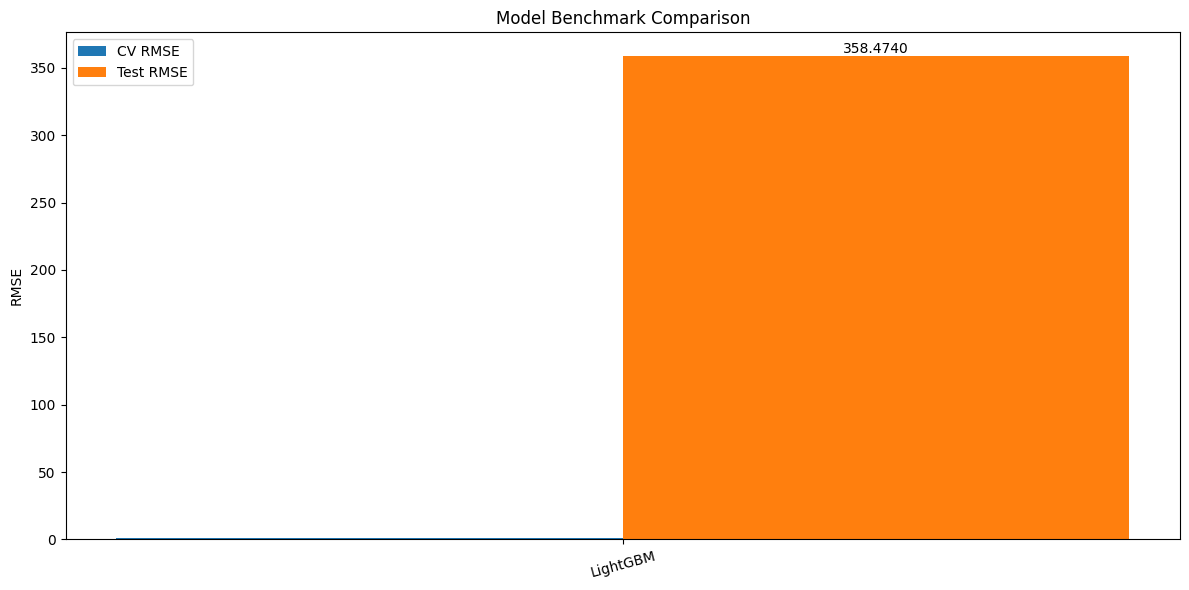


BEST MODEL:
LightGBM


In [24]:
plt.figure(figsize=(12, 6))

x = np.arange(len(results_df))

width = 0.35

plt.bar(
    x - width / 2,
    results_df["CV_RMSE"],
    width=width,
    label="CV RMSE"
)

plt.bar(
    x + width / 2,
    results_df["Test_RMSE"],
    width=width,
    label="Test RMSE"
)

plt.xticks(
    x,
    results_df["Model"],
    rotation=15
)

plt.ylabel("RMSE")
plt.title("Model Benchmark Comparison")

plt.legend()

for i, v in enumerate(results_df["Test_RMSE"]):
    plt.text(
        i + width / 2,
        v,
        f"{v:.4f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

best_model_name = results_df.iloc[0]["Model"]

print("\nBEST MODEL:")
print(best_model_name)


In [25]:

sumbission_test_p = x_pipeline.transform(sumbission_test)
model = MultiOutputRegressor(
        LGBMRegressor(
            random_state=RANDOM_STATE,
            verbose=-1,
            **all_results[0]["Params"]
        )
    )
X_p = x_pipeline.transform(X)
if USE_LOG_TARGET:
    y_p = np.log1p(Y)
else:
    y_p = Y.copy()
model = model.fit(X_p, y_p)
preds = np.expm1(model.predict(sumbission_test_p))
y_pred = pd.DataFrame(preds, index=sumbission_test.index, columns=y_test.columns)

y_pred.to_csv("submission.csv")

TOP SCORE: 302.69734

Что было проверено:
- повышение threshold по variance и correlation приводит к ухудшению результатов
- добавление дополнительных фич приводит к ухудшению результатов (скорее всего плохие фичи)
- модели кроме lgb плохо себя показывают
- вычисление SI вместо предсказания улучшает ситуацию слегка, но непонятно насколько это законно

TODO:
- попробовать скластеризовать по fr_* фичам и обучить с groupkfold на основе кластеров